<a href="https://colab.research.google.com/github/MichelleIhetu/ML_Learning_Track/blob/main/Michelle_Knowledge_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Set Up
We decided to use a Neo4j knowledge graph to show the 5 different categories of medical devices (regulatory filing, medical devices, corporate entities, hardware modules, and clinical functions) and explicity show how they relate to each other

In [9]:
!git clone https://github.com/MedHive/ucb-datascience


fatal: destination path 'ucb-datascience' already exists and is not an empty directory.


In [10]:
pip install neo4j

Solve it by using offical neo4j driver to parse the docs differently

In [11]:
from neo4j import GraphDatabase

URI = "neo4j+s://fba75bfc.databases.neo4j.io" #My database URI is not working
AUTH = ("neo4j", "qP_ARQYOab09Xo0IdyxCocIL2WoneE7BCAEMB4tqCKA")

driver = GraphDatabase.driver(URI, auth=AUTH)

Retrive nodes and edges csv file then upload it to collab to extract replationships follows the 501k ontology format to create query

In [12]:
from google.colab import files
FDA_Edges_Upload = files.upload()

Saving fda_edges.csv to fda_edges.csv


In [13]:
FDA_Nodes_Upload = files.upload()

Saving fda_nodes.csv to fda_nodes.csv


In [14]:
import spacy
nlp = spacy.load('en_core_web_sm') #Loads pretrained English model

In [15]:
edges_str= str(FDA_Edges_Upload)
nodes_str= str(FDA_Nodes_Upload)

In [16]:
edges= nlp(edges_str)
nodes = nlp(nodes_str)

In [17]:
for ent in nodes.ents: #contains all recognized texts
    print(ent.text, ent.start_char, ent.end_char, ent.label_)

Bedside Monitor\nCapnostream10,Device 102 139 ORG
Bedside Monitor\nOridion Medical 1987 Ltd. 140 182 ORG
Capnography Inc. 213 229 ORG
Submitter\nSanford Brown,Person,Regulatory Affairs Director\nFDA 238 302 ORG
Agency 303 309 ORG


In [18]:
for ent in edges.ents: #contains all recognized texts
    print(ent.text, ent.start_char, ent.end_char, ent.label_)

b':START_ID,:END_ID 18 37 PERSON
predicate\nCapnostream20,Oridion Medical 1987 Ltd. 47 97 ORG
Manufacturer\nCapnostream10,Oridion Medical 1987 Ltd. 114 167 ORG
Capnography Inc. 206 222 ORG
Regulator\nCapnostream20,FDA 240 268 ORG
Substantial Equivalence\nCapnostream10,FDA 280 322 GPE
Substantial Equivalence\nSanford Brown 334 372 PERSON
Oridion Medical 1987 Ltd. 373 398 ORG
Works_For\nCapnostream20,MiniMediCO2,includes_module 411 463 GPE
Function\nMP100,SpO2 Measurement 624 656 PERSON
Function\nCapnostream20,CO2 Measurement 666 705 ORG
K060065,issued_letter 840 861 PERSON


Install visual libaries

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


Explicity write out the relationship

In [20]:
NODES = [
    ("K060065",         {"label": "K060065",              "type": "Submission"}),
    ("Capnostream20",   {"label": "Capnostream20",         "type": "Device"}),
    ("Capnostream10",   {"label": "Capnostream10",         "type": "Device"}),
    ("OridionMedical",  {"label": "Oridion Medical\n1987 Ltd.", "type": "Company"}),
    ("OridionCapnography", {"label": "Oridion\nCapnography Inc.", "type": "Company"}),
    ("SanfordBrown",    {"label": "Sanford Brown",         "type": "Person"}),
    ("FDA",             {"label": "FDA",                   "type": "Agency"}),
    ("MiniMediCO2",     {"label": "MiniMediCO2",           "type": "Module"}),
    ("MP100",           {"label": "MP100",                 "type": "Module"}),
    ("CO2",             {"label": "CO2\nMeasurement",      "type": "Function"}),
    ("SpO2",            {"label": "SpO2\nMeasurement",     "type": "Function"}),
]

EDGES = [
    ("Capnostream20",   "OridionMedical",    "manufactured_by"),
    ("Capnostream10",   "OridionMedical",    "manufactured_by"),
    ("OridionCapnography", "FDA",            "submitted_to"),
    ("Capnostream20",   "FDA",               "cleared_by"),
    ("Capnostream10",   "FDA",               "cleared_by"),
    ("SanfordBrown",    "OridionMedical",    "employed_by"),
    ("Capnostream20",   "MiniMediCO2",       "includes_module"),
    ("Capnostream20",   "MP100",             "includes_module"),
    ("Capnostream10",   "MiniMediCO2",       "includes_module"),
    ("MiniMediCO2",     "CO2",               "measures"),
    ("MP100",           "SpO2",              "measures"),
    ("Capnostream20",   "CO2",               "intended_use"),
    ("Capnostream20",   "SpO2",              "intended_use"),
    ("Capnostream10",   "CO2",               "intended_use"),
    ("FDA",             "K060065",           "issued_letter"),
]

In [21]:
TYPE_COLORS = {
    "Submission": "#7F77DD",
    "Device":     "#1D9E75",
    "Company":    "#378ADD",
    "Module":     "#D85A30",
    "Function":   "#BA7517",
    "Person":     "#888780",
    "Agency":     "#888780",
}

In [22]:
def node_colors(G):
    return [TYPE_COLORS.get(G.nodes[n].get("type", "Agency"), "#aaa") for n in G.nodes]


In [23]:
def node_labels(G):
    return {n: G.nodes[n].get("label", n) for n in G.nodes}

def draw_graph(G, title, pos=None, figsize=(9, 6), description=""):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("#F8F8F6")
    ax.set_facecolor("#F8F8F6")

    if pos is None:
        pos = nx.spring_layout(G, seed=42, k=2.2)

    colors = node_colors(G)
    labels = node_labels(G)
    edge_labels = {(s, t): d["relation"] for s, t, d in G.edges(data=True)}

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1800,
                           alpha=0.92, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7,
                            font_color="white", font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#999", arrows=True,
                           arrowsize=18, width=1.2,
                           connectionstyle="arc3,rad=0.07", ax=ax,
                           node_size=1800)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=6.5, font_color="#555",
                                 bbox=dict(fc="#F8F8F6", ec="none", alpha=0.7),
                                 ax=ax)

    seen = {}
    for n in G.nodes:
        t = G.nodes[n].get("type", "Agency")
        if t not in seen:
            seen[t] = TYPE_COLORS.get(t, "#aaa")
    patches = [mpatches.Patch(color=c, label=t) for t, c in seen.items()]
    ax.legend(handles=patches, loc="lower left", fontsize=7,
                  framealpha=0.8, edgecolor="#ccc")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=12, color="#222")
    if description:
        fig.text(0.5, 0.01, description, ha="center", fontsize=7.5,
                     color="#666", style="italic", wrap=True)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

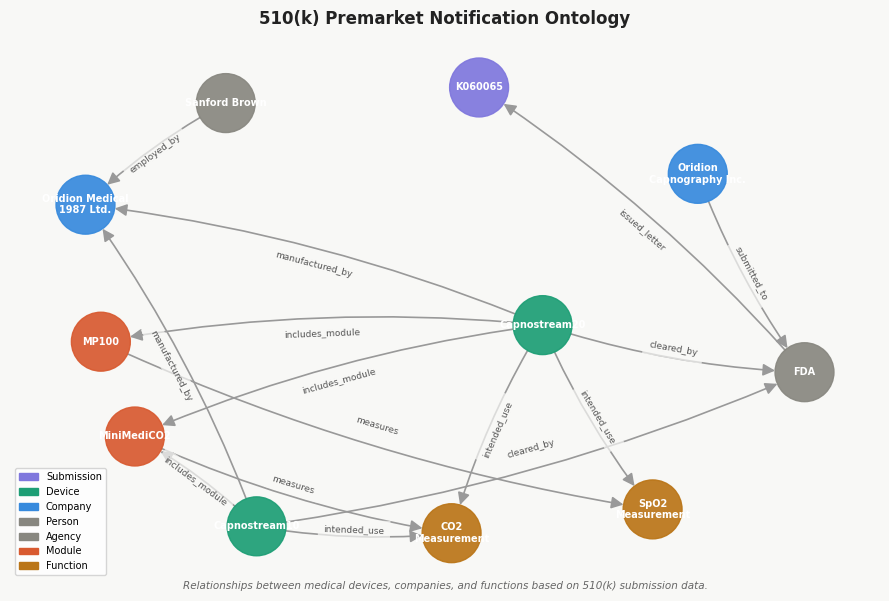

In [24]:
# Create a graph object
G = nx.DiGraph()

# Add nodes with attributes
for node_id, attributes in NODES:
    G.add_node(node_id, **attributes)

# Add edges with attributes
for source, target, relation in EDGES:
    G.add_edge(source, target, relation=relation)

# Draw the graph
draw_graph(G, title="510(k) Premarket Notification Ontology", description="Relationships between medical devices, companies, and functions based on 510(k) submission data.")

This is the base of the knowledge graph where we show the basic relationship between the manufactuer, function and who cleared it.The device claims the function, and the embedded module implements it.

Left Cluster shows who implemented it aka organizational provience
Central Cluster show what the medical device consits of and how it is cleared


Right Cluster shows what the medical device measures Sp02. Both devices fire intended use

In [25]:
def build_subgraph(node_ids, edge_rels):
    G = nx.DiGraph()
    node_dict = dict(NODES)
    for nid in node_ids:
        if nid in node_dict:
            G.add_node(nid, **node_dict[nid])
    nset = set(node_ids)
    for s, t, rel in EDGES:
        if s in nset and t in nset and rel in edge_rels:
            G.add_edge(s, t, relation=rel)
    return G

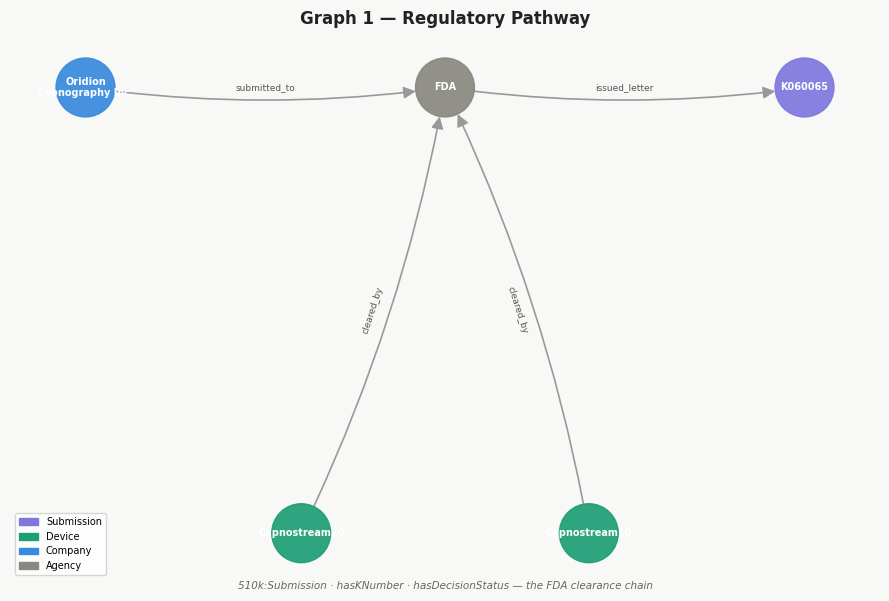

In [26]:
G1 = build_subgraph(
    node_ids=["K060065", "Capnostream20", "Capnostream10", "OridionCapnography", "FDA"],
    edge_rels=["submitted_to", "cleared_by", "issued_letter"]
)
pos1 = {
    "OridionCapnography": (-1.5,  0),
    "FDA":                ( 0,    0),
    "K060065":            ( 1.5,  0),
    "Capnostream20":      (-0.6, -1.2),
    "Capnostream10":      ( 0.6, -1.2),
}
draw_graph(G1, "Graph 1 — Regulatory Pathway", pos=pos1,
           description="510k:Submission · hasKNumber · hasDecisionStatus — the FDA clearance chain")



The Regulatory Pathway knowledge graph shows us the medical device - Capnostream is cleared by the FDA from the Oridion Capnography

 owl:ObjectProperty (Category)  has a domain and a range — a subject and an object. The direction of the arrow shows who is doing what to whom.

 Disscussion Point:
 Why did I have Capnostream point to FDA?
 - The device went through FDA
 *Capnostream was cleared by the FDA*
 Subject: Capnostream
 Property: is_cleared
 Agent: FDA

 The arrow is just stating a fact about the device not the FDA

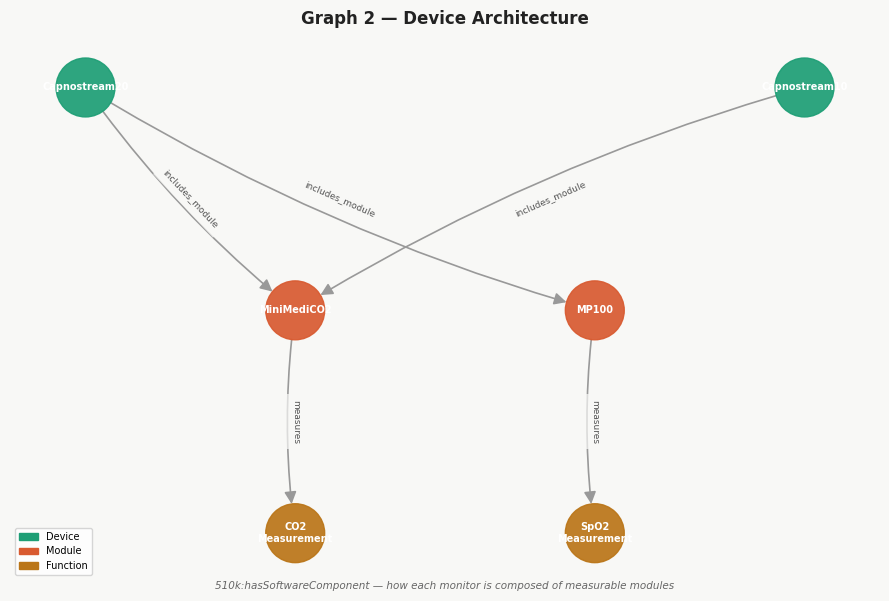

In [27]:
G2 = build_subgraph(
    node_ids=["Capnostream20", "Capnostream10", "MiniMediCO2", "MP100", "CO2", "SpO2"],
    edge_rels=["includes_module", "measures"]
)
pos2 = {
    "Capnostream20": (-1.2,  1.2),
    "Capnostream10": ( 1.2,  1.2),
    "MiniMediCO2":   (-0.5,  0),
    "MP100":         ( 0.5,  0),
    "CO2":           (-0.5, -1.2),
    "SpO2":          ( 0.5, -1.2),
}
draw_graph(G2, "Graph 2 — Device Architecture", pos=pos2,
           description="510k:hasSoftwareComponent — how each monitor is composed of measurable modules")

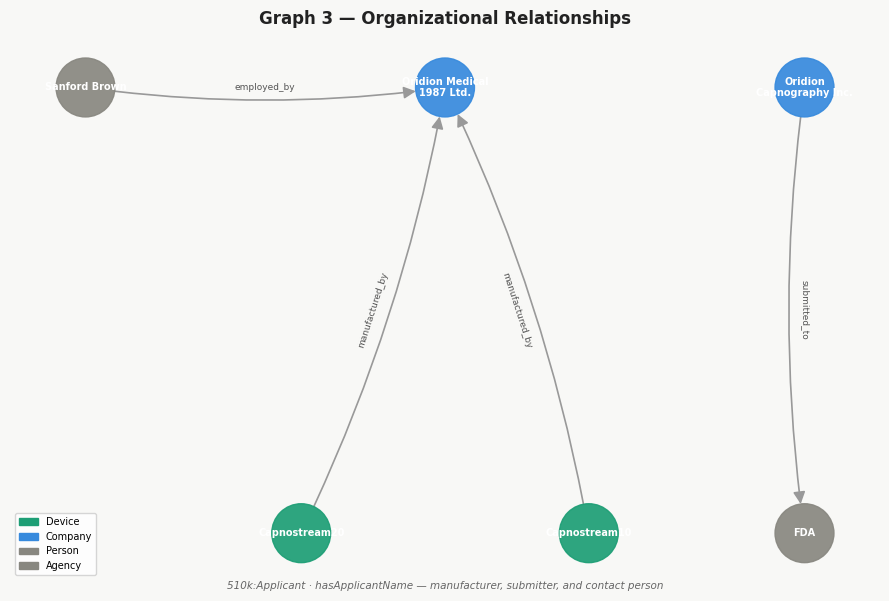

In [28]:
G3 = build_subgraph(
    node_ids=["Capnostream20", "Capnostream10", "OridionMedical",
              "OridionCapnography", "SanfordBrown", "FDA"],
    edge_rels=["manufactured_by", "employed_by", "submitted_to"]
)
pos3 = {
    "OridionMedical":     ( 0,    0),
    "OridionCapnography": ( 1.5,  0),
    "SanfordBrown":       (-1.5,  0),
    "Capnostream20":      (-0.6, -1.3),
    "Capnostream10":      ( 0.6, -1.3),
    "FDA":                ( 1.5, -1.3),
}
draw_graph(G3, "Graph 3 — Organizational Relationships", pos=pos3,
           description="510k:Applicant · hasApplicantName — manufacturer, submitter, and contact person")

Why is Oridion Capnography by itself?

Graph 3 shows the relationship of manufactuer, company and FDA

Standford Brown works at Oridion Medical which is the medtech manufacturer
Oridion Capnography Inc is responsible for the regulations with FDA

Two seperate legal entities so two seperate nodes

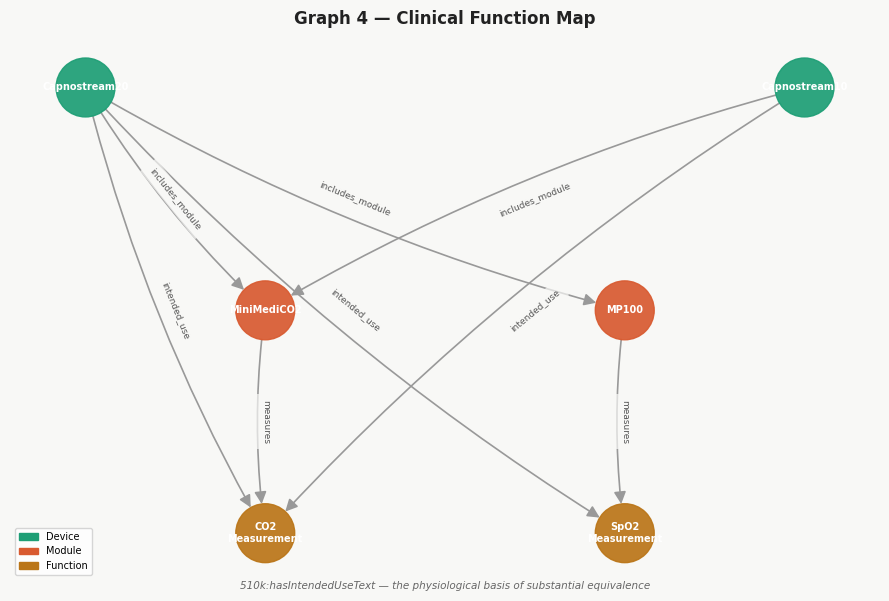

In [29]:
G4 = build_subgraph(
    node_ids=["Capnostream20", "Capnostream10", "MiniMediCO2", "MP100", "CO2", "SpO2"],
    edge_rels=["intended_use", "measures", "includes_module"]
)
pos4 = {
    "Capnostream20": (-1.2,  1.2),
    "Capnostream10": ( 1.2,  1.2),
    "MiniMediCO2":   (-0.6,  0),
    "MP100":         ( 0.6,  0),
    "CO2":           (-0.6, -1.2),
    "SpO2":          ( 0.6, -1.2),
}
draw_graph(G4, "Graph 4 — Clinical Function Map", pos=pos4,
           description="510k:hasIntendedUseText — the physiological basis of substantial equivalence")

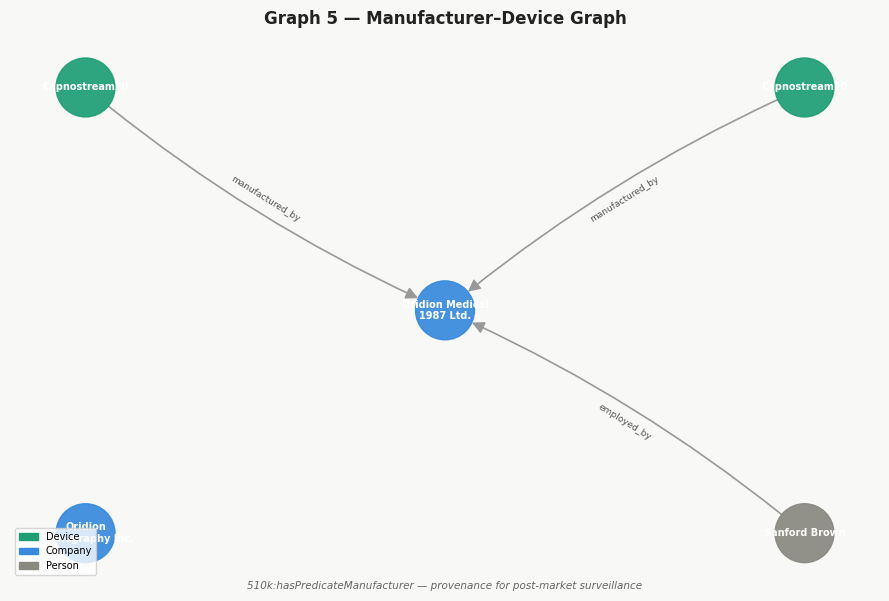

In [30]:
G5 = build_subgraph(
    node_ids=["Capnostream20", "Capnostream10", "OridionMedical",
              "OridionCapnography", "SanfordBrown"],
    edge_rels=["manufactured_by", "employed_by"]
)
pos5 = {
    "OridionMedical":     ( 0,    0),
    "Capnostream20":      (-1.3,  1),
    "Capnostream10":      ( 1.3,  1),
    "OridionCapnography": (-1.3, -1),
    "SanfordBrown":       ( 1.3, -1),
}
draw_graph(G5, "Graph 5 — Manufacturer–Device Graph", pos=pos5,
           description="510k:hasPredicateManufacturer — provenance for post-market surveillance")

Why did I include  Oridion Capnography?

It has no manufactured_by or employed_by edge in the data but I wanted to show that manufactuer and compliance are two seperate legal entities.

It shows that no one at the manufacturing level has a direct line to the FDA so no relationship means no edge

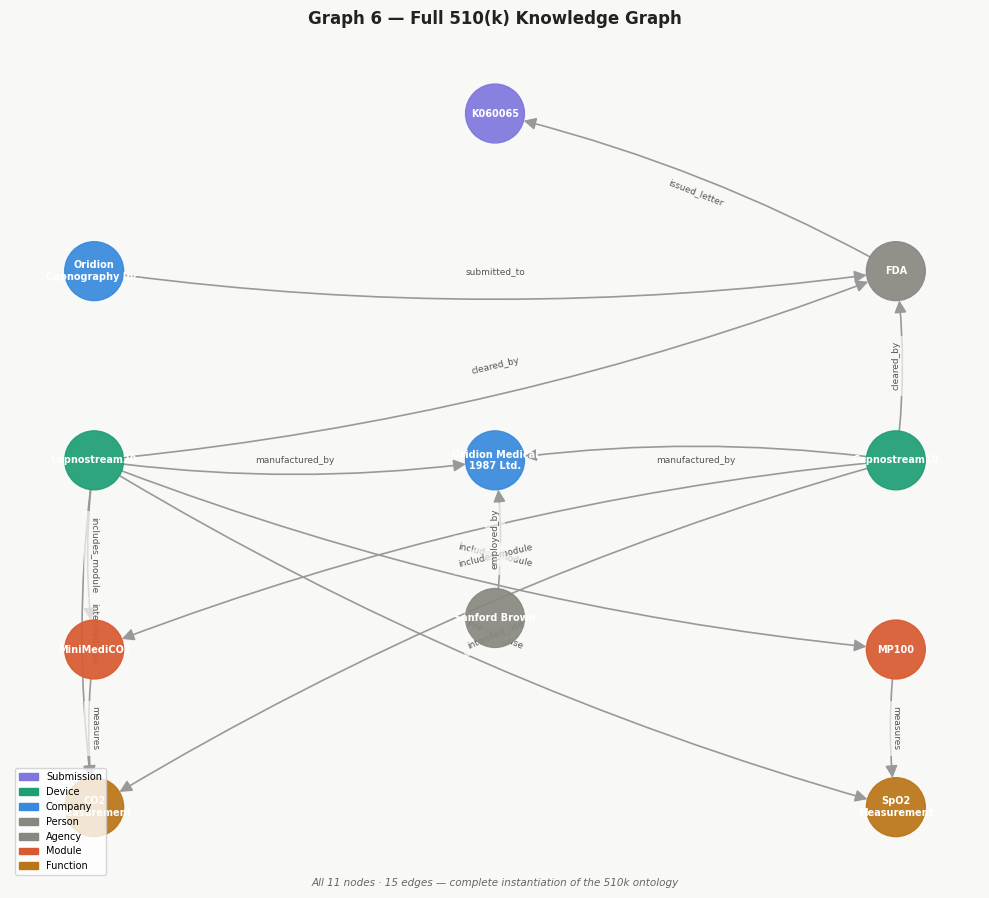

In [31]:
G6 = nx.DiGraph()
node_dict = dict(NODES)
for nid, attrs in NODES:
    G6.add_node(nid, **attrs)
for s, t, rel in EDGES:
    G6.add_edge(s, t, relation=rel)

pos6 = {
    "K060065":            ( 0,    2.2),
    "FDA":                ( 1.4,  1.2),
    "OridionCapnography": (-1.4,  1.2),
    "Capnostream20":      (-1.4,  0),
    "Capnostream10":      ( 1.4,  0),
    "OridionMedical":     ( 0,    0),
    "SanfordBrown":       ( 0,   -1),
    "MiniMediCO2":        (-1.4, -1.2),
    "MP100":              ( 1.4, -1.2),
    "CO2":                (-1.4, -2.2),
    "SpO2":               ( 1.4, -2.2),
}
draw_graph(G6, "Graph 6 — Full 510(k) Knowledge Graph", pos=pos6,
           figsize=(10, 9),
           description="All 11 nodes · 15 edges — complete instantiation of the 510k ontology")


In [32]:
print(NODES)

[('K060065', {'label': 'K060065', 'type': 'Submission'}), ('Capnostream20', {'label': 'Capnostream20', 'type': 'Device'}), ('Capnostream10', {'label': 'Capnostream10', 'type': 'Device'}), ('OridionMedical', {'label': 'Oridion Medical\n1987 Ltd.', 'type': 'Company'}), ('OridionCapnography', {'label': 'Oridion\nCapnography Inc.', 'type': 'Company'}), ('SanfordBrown', {'label': 'Sanford Brown', 'type': 'Person'}), ('FDA', {'label': 'FDA', 'type': 'Agency'}), ('MiniMediCO2', {'label': 'MiniMediCO2', 'type': 'Module'}), ('MP100', {'label': 'MP100', 'type': 'Module'}), ('CO2', {'label': 'CO2\nMeasurement', 'type': 'Function'}), ('SpO2', {'label': 'SpO2\nMeasurement', 'type': 'Function'})]
